# Redes Convolucionales

Generado por la cátedra de Introducción a la Inteligencia Artificial de la  Licenciatura en Ciencias de la Computación - UNR

Autor: Nicolás Soncini

In [ ]:
# Patch para GPU de Ariel (AMD RX 6750 XT)
%env HSA_OVERRIDE_GFX_VERSION=10.3.0
%env MIOPEN_DEBUG_FIND_ENFORCE=2

env: HSA_OVERRIDE_GFX_VERSION=10.3.0
env: MIOPEN_DEBUG_FIND_ENFORCE=2


In [2]:
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

# Tensorflow es un a librería o motor de machine learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
# chequeamos las versiones de las librerias y si tenemos GPU
# (dato de color: la traducción de "library" debería ser biblioteca, y no librería)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Keras version: {keras.__version__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.16k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Keras version: 3.13.2


In [3]:
import IPython

## Dataset

In [4]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})


In [5]:
LABELS = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

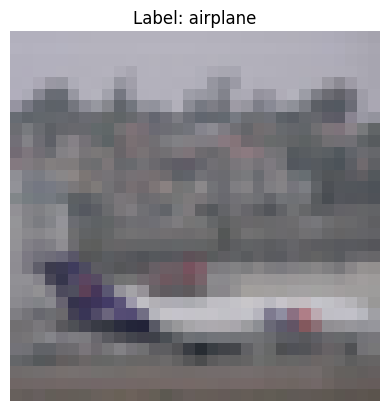

In [6]:
ds_train = ds['train']
ds_test = ds['test']

plt.imshow(ds_train[0]['img'])
plt.title(f'Label: {LABELS[ds_train[0]['label']]}')
plt.axis('off')
plt.show()

Se extrae todo el dataset a memoria y se normalizan las imágenes al rango $[0, 1]$:

In [7]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0

## Ejercicio 1. Visión por Computadora

In [8]:
def plot_history_graphics(history):
    fig = plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Error de entrenamiento')
    plt.plot(history.history['val_loss'], label='Error de validación')
    plt.title('Curvas de error (categorical cross-entropy)')
    plt.xlabel('Épocas')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy del entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Accuracy de validación')
    plt.title('Curvas de accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

#### Definiendo la red

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Flatten(name='flatten'),
    # Asumiendo estas son Relu como en el tutorial de Tensorflow
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    # Usamos softmax en vez de una capa densa con activación lineal al final (respecto al tutorial)
    layers.Dense(10, activation='softmax', name='output')
])

I0000 00:00:1781536767.790815      39 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11008 MB memory:  -> device: 0, name: AMD Radeon RX 6750 XT, pci bus id: 0000:01:00.0


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,506 (1.60 MB)

 Trainable params: 418,506 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
y_train

array([0, 6, 0, ..., 1, 1, 5], shape=(50000,))

Se puede observar que a cada elemento del conjunto de entrenamiento le corresponde en el arreglo `y_train` un número que identifica su clase.
Por lo tanto, se requiere que la función de loss utilizada acepte las clases del dataset de esta forma.
La función `keras.losses.SparseCategoricalCrossentropy()` utilizada en el tutorial de Tensorflow indica en su documentación que espera clases justamente de esta forma, como enteros.

In [ ]:
model.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

Se normalizan las imágenes del conjunto de test también al rango $[0,1]$:

In [9]:
x_test = np.array(ds_test['img'])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [ ]:
y_test

array([3, 8, 8, ..., 5, 1, 7], shape=(10000,))

In [10]:
def train_model_rounds_ex1(model, rounds: int, epochs: int, folder_name: str):
    best_model = (0, 0, None)

    for r in range(rounds):
        # Se mantiene en pantalla solamente la salida de entrenamiento de la última ronda
        # para evitar que el output final sea muy largo.
        IPython.display.clear_output(wait=True)

        checkpoint_dir = f'./chk/{folder_name}/round_{r}/'
        callbacks = [
            keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_dir+"{epoch}.keras",
                save_best_only=True,
                monitor="val_accuracy",
                verbose=1,
            )
        ]

        # A diferencia del tutorial, se separan parte de los datos para validación,
        # en vez de usar el conjunto de test como tal.
        x_train_split, x_val_split, y_train_split, y_val_split = \
            train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

        # Hay que clonar el modelo original para poder entrenarlo desde cero cada vez.
        model_cur = keras.models.clone_model(model)

        history_cur = model_cur.fit(
            x_train_split, y_train_split, epochs=epochs, callbacks=callbacks,
            validation_data=(x_val_split, y_val_split)
        )

        checkpoints = [checkpoint_dir + "/" + name for name in os.listdir(checkpoint_dir)]
        latest_checkpoint = max(checkpoints, key=os.path.getctime)
        best_chk = keras.models.load_model(latest_checkpoint)
        test_loss, test_accuracy = best_chk.evaluate(x_test, y_test, verbose=0)
        best_model = max(best_model, (test_accuracy, test_loss, history_cur))

    return best_model

In [ ]:
ROUNDS = 5
EPOCHS = 10 # Default del tutorial de Tensorflow
best_model_10ep = train_model_rounds_ex1(model, ROUNDS, EPOCHS, "ex1_10ep")

Epoch 1/10
1398/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2715 - loss: 1.9392
Epoch 1: val_accuracy improved from None to 0.51560, saving model to ./chk/ex1_10ep/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex1_10ep/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3774 - loss: 1.6839 - val_accuracy: 0.5156 - val_loss: 1.3272
Epoch 2/10
1398/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5327 - loss: 1.2888
Epoch 2: val_accuracy improved from 0.51560 to 0.57360, saving model to ./chk/ex1_10ep/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex1_10ep/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5536 - loss: 1.2315 - val_accuracy: 0.5736 - val_loss: 1.2050
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6225 - loss: 1.0649
Epoch 3: val_accuracy improved from 0.57360 to 0.65300, saving model to ./chk/ex1_10ep/round_4/3.keras

Epoch 3: finished saving model to ./chk/ex1_10ep/round_4/3.

Se utilizan checkpoints para guardar el mejor accuracy obtenido entre los obtenidos durante una ronda de entrenamiento.

Además, se decidió ejecutar varias rondas de entrenamiento para obtener el mejor accuracy entre todas, debido a que se observaron variaciones de alrededor de $1-2\%$ que pueden afectar a la medición de las mejoras de la arquitectura de la CNN propuestas más adelante.

A diferencia del tutorial, separamos parte de los datos para validación, en vez de usar el conjunto de test como tal. Esto nos permitirá tener mejores medidas del error de la red entrenada (TODO: Ok? Mejor explicación?):

In [ ]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

In [ ]:
def plot_history_graphics(history):
    fig = plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Error de entrenamiento')
    plt.plot(history.history['val_loss'], label='Error de validación')
    plt.title('Curvas de error (categorical cross-entropy)')
    plt.xlabel('Épocas')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy del entrenamiento') # TODO: Cambiar por porcentaje de error con 1-acc?
    plt.plot(history.history['val_accuracy'], label='Accuracy de validación')
    plt.title('Curvas de accuracy')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

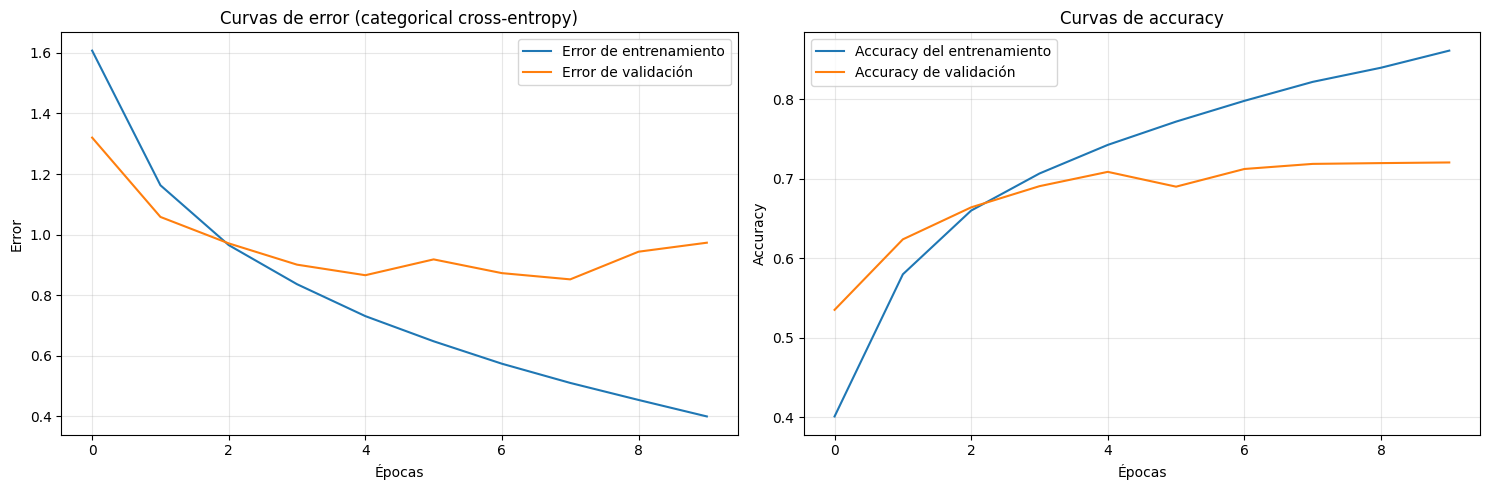

In [ ]:
plot_history_graphics(best_model_10ep[2])

In [ ]:
print(f'Categorical cross-entropy: {best_model_10ep[1]}')
print(f'Accuracy: {best_model_10ep[0]:.4f} ({best_model_10ep[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_10ep[0]:.4f} ({(1-best_model_10ep[0])*100:.2f}%)')

Categorical cross-entropy: 0.9903419017791748
Accuracy: 0.7187 (71.87%)
Error Rate: 0.2813 (28.13%)


TODO: Observaciones // redacción // formato Latex para números // revisar valores, etc-> El error de entrenamiento baja, y el accuracy de entrenamiento sube. Lo mismo sucede al principio con el conjunto de validación, pero luego se estanca su crecimiento del accuracy, e incluso su error sube algo más en las últimas épocas. La accuracy sobre el conjunto de test es de 73%, y el error de 0.96, probablemente se pueden mejorar (disminuir el error, y aumentar el accuracy).

A pesar de esto, parece que el accuracy se encuentra en aumento con una pendiente considerable, y lo mismo para el descenso del error de entrenamiento.
Es posible entonces que el error de entrenamiento mejore con mayor cantidad de épocas. Elegimos arbitrariamente el doble, 20 épocas.

In [ ]:
ROUNDS = 5
EPOCHS = 20
best_model_20ep = train_model_rounds_ex1(model, ROUNDS, EPOCHS, "ex1_20ep")

Epoch 1/20
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3027 - loss: 1.8588
Epoch 1: val_accuracy improved from None to 0.48920, saving model to ./chk/ex1_20ep/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex1_20ep/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3991 - loss: 1.6211 - val_accuracy: 0.4892 - val_loss: 1.4479
Epoch 2/20
1401/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5558 - loss: 1.2315
Epoch 2: val_accuracy improved from 0.48920 to 0.61880, saving model to ./chk/ex1_20ep/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex1_20ep/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5764 - loss: 1.1703 - val_accuracy: 0.6188 - val_loss: 1.0887
Epoch 3/20
1402/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6462 - loss: 0.9912
Epoch 3: val_accuracy improved from 0.61880 to 0.68140, saving model to ./chk/ex1_20ep/round_4/3.keras

Epoch 3: finished saving model to ./chk/ex1_20ep/round_4/3.

In [ ]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

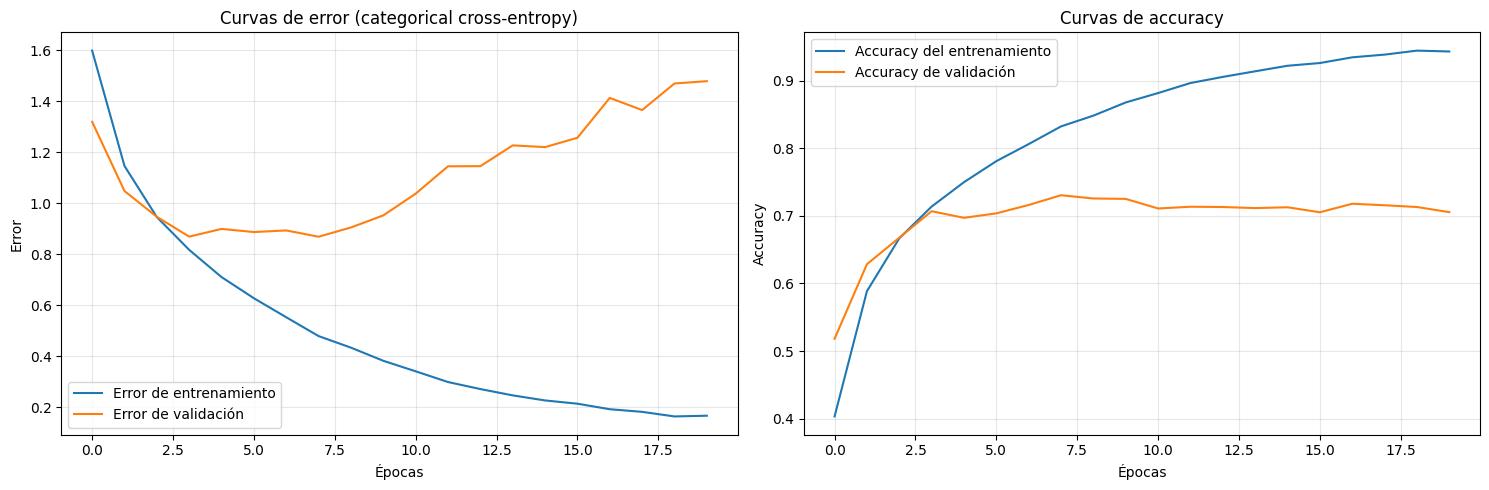

In [ ]:
plot_history_graphics(best_model_20ep[2])

In [ ]:
print(f'Categorical cross-entropy: {best_model_20ep[1]}')
print(f'Accuracy: {best_model_20ep[0]:.4f} ({best_model_20ep[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_20ep[0]:.4f} ({(1-best_model_20ep[0])*100:.2f}%)')

Categorical cross-entropy: 0.8627658486366272
Accuracy: 0.7261 (72.61%)
Error Rate: 0.2739 (27.39%)


TODO:
Es claro con una mayor cantidad de épocas que el estancamiento del accuracy del conjunto de validación observado con 10 épocas es producto de overfitting, lo cual se evidencia especialmente con 20 épocas. Si bien a mayor cantidad de épocas se logra un menor error en el conjunto de test, el accuracy del conjunto de validación se mantiene en torno al 70%, y su error de categorical cross-entropy de hecho aumenta partiendo de alrededor de la 10° época. TODO: Redacción / números

Además, ambas métricas retornan peores resultados para el conjunto de test respecto a las vistas con 10 épocas: un accuracy de 68% (5% menos) y un loss mayor de 1.42.

Dicho esto, plantearemos una modificación a la arquitectura de la CNN que permita obtener una mejora en el error obtenido:

#### TODO: ENCONTRAR UN CAMBIO QUE AYUDE A MEJORAR LA PERFORMANCE DE LA RED!!!

In [ ]:
model_enhanced = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
    layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
    layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
    layers.Flatten(name='flatten'),
    #layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(10, activation='softmax', name='output')
])

In [ ]:
model_enhanced.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 318,922 (1.22 MB)

 Trainable params: 318,922 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_enhanced.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train_split, x_val_split, y_train_split, y_val_split = \
    train_test_split(x_train, y_train, test_size=0.1, stratify=y_train)

In [ ]:
history_enhanced = model_enhanced.fit(
    x_train_split, y_train_split, epochs=10,
    validation_data=(x_val_split, y_val_split)
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4103 - loss: 1.5935 - val_accuracy: 0.5414 - val_loss: 1.2896
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6044 - loss: 1.1070 - val_accuracy: 0.6414 - val_loss: 0.9997
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6839 - loss: 0.8941 - val_accuracy: 0.6872 - val_loss: 0.8754
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.7345 - loss: 0.7608 - val_accuracy: 0.7124 - val_loss: 0.8461
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7632 - loss: 0.6748 - val_accuracy: 0.7324 - val_loss: 0.7643
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7911 - loss: 0.5961 - val_accuracy: 0.7270 - val_loss: 0.8315
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8116 - loss: 0.5335 - val_accuracy: 0.7466 - val_loss: 0.7559
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8315 - loss: 0

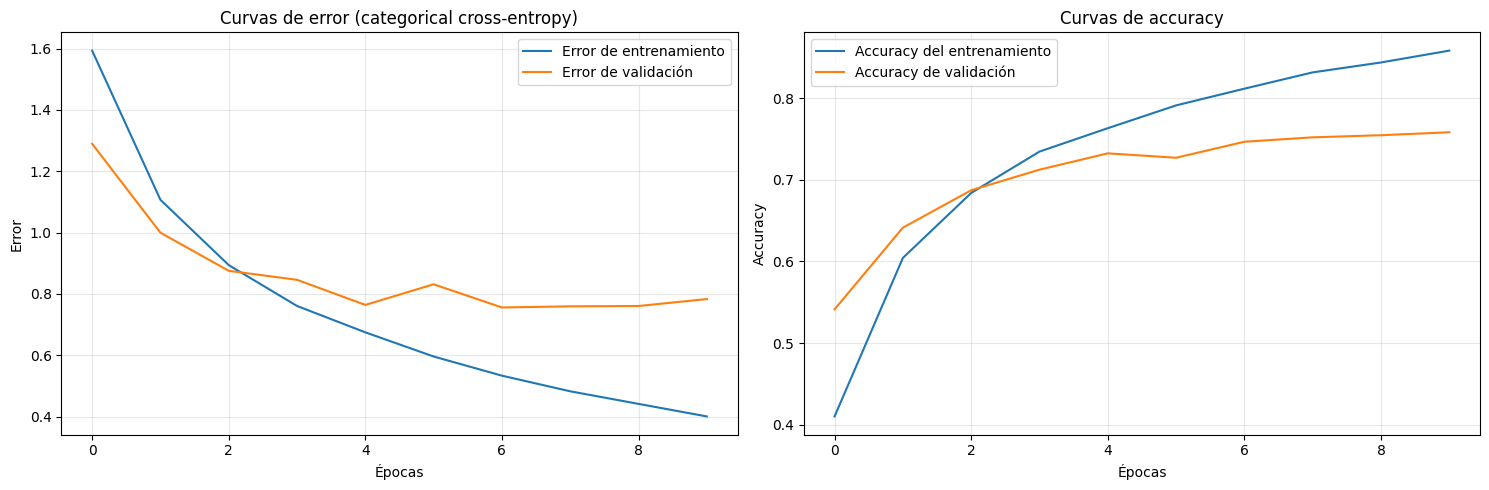

In [ ]:
plot_history_graphics(history_enhanced)

In [ ]:
model_enhanced.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7563 - loss: 0.7982


[0.7982431650161743, 0.7562999725341797]

## Ejercicio 2. Dropout

Función para crear los modelos con dropout.

In [11]:
def create_model_dropout(prob, two_drops): # two_drops es para hacer uno o dos dropouts, capaz se puede hacer mas lindo
    model_drop1 = keras.Sequential([
        keras.Input(shape=(32, 32, 3)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
        layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
        layers.MaxPooling2D(name='maxpool2d_2'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
        layers.Dropout(prob, name='dropout_1'),
        layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
        layers.Flatten(name='flatten'),
        layers.Dense(64, activation='relu', name='dense_1')
    ])
    if (two_drops):
        model_drop = keras.Sequential([
            model_drop1,
            layers.Dropout(prob, name='dropout_2'),
        ])
    else:
        model_drop = model_drop1

    return keras.Sequential([
        model_drop,
        layers.Dense(128, activation='relu', name='dense_2'),
        layers.Dense(10, activation='softmax', name='output')
    ])

Se entrenan 4 modelos, para cada uno se realizan 5 rondas de entrenamiento y se selecciona la mejor red de las 5.

In [20]:
ROUNDS = 5
EPOCHS = 20

In [ ]:
model_drop_11 = create_model_dropout(0.2, False)
model_drop_11.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_drop_11.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)

best_model_drop_11 = train_model_rounds_ex1(model_drop_11, ROUNDS, EPOCHS, "ex2_drop_11")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2946 - loss: 1.8738
Epoch 1: val_accuracy improved from None to 0.54880, saving model to ./chk/ex2_drop_11/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex2_drop_11/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.4027 - loss: 1.6093 - val_accuracy: 0.5488 - val_loss: 1.2320
Epoch 2/20
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5817 - loss: 1.1624
Epoch 2: val_accuracy improved from 0.54880 to 0.65660, saving model to ./chk/ex2_drop_11/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex2_drop_11/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6059 - loss: 1.1030 - val_accuracy: 0.6566 - val_loss: 1.0104
Epoch 3/20
1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6823 - loss: 0.9101
Epoch 3: val_accuracy improved from 0.65660 to 0.70500, saving model to ./chk/ex2_drop_11/round_4/3.keras

Epoch 3: finished saving model to ./chk/e

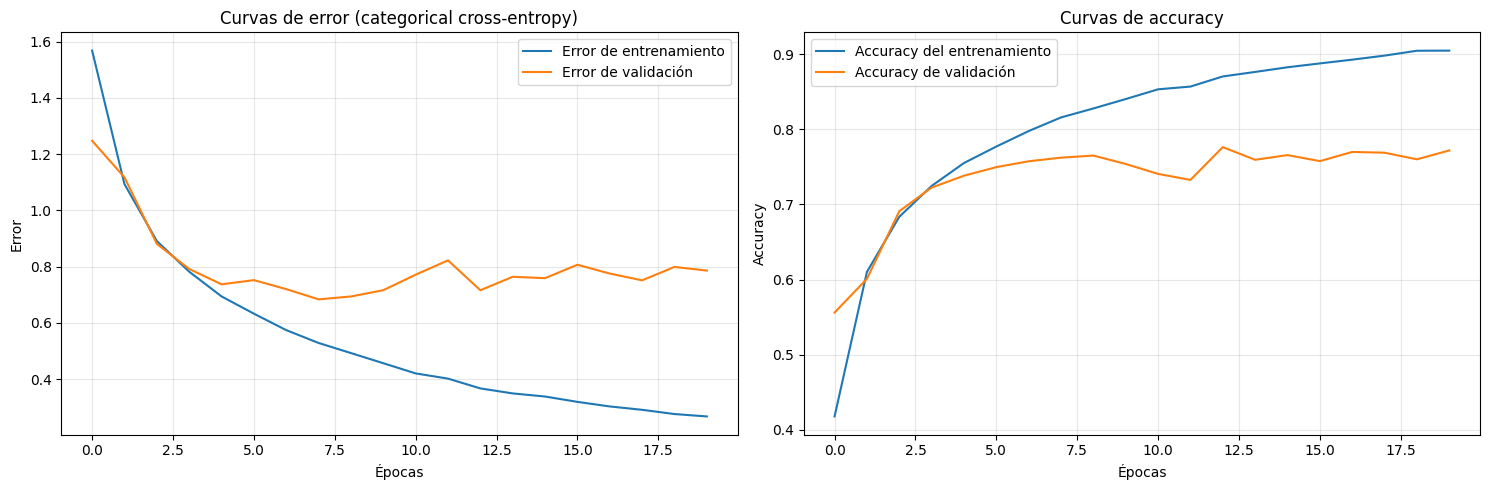

In [ ]:
plot_history_graphics(best_model_drop_11[2])

In [ ]:
print(f'Categorical cross-entropy: {best_model_drop_11[1]:.4f}')
print(f'Accuracy: {best_model_drop_11[0]:.4f} ({best_model_drop_11[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_drop_11[0]:.4f} ({(1-best_model_drop_11[0])*100:.2f}%)')

Categorical cross-entropy: 0.7266
Accuracy: 0.7706 (77.06%)
Error Rate: 0.2294 (22.94%)


In [ ]:
model_drop_12 = create_model_dropout(0.2, True)
model_drop_12.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_drop_12.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
best_model_drop_12 = train_model_rounds_ex1(model_drop_12, ROUNDS, EPOCHS, "ex2_drop_12")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2349 - loss: 2.0195
Epoch 1: val_accuracy improved from None to 0.50720, saving model to ./chk/ex2_drop_12/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex2_drop_12/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.3394 - loss: 1.7677 - val_accuracy: 0.5072 - val_loss: 1.3420
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5201 - loss: 1.3215
Epoch 2: val_accuracy improved from 0.50720 to 0.59700, saving model to ./chk/ex2_drop_12/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex2_drop_12/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - accuracy: 0.5448 - loss: 1.2556 - val_accuracy: 0.5970 - val_loss: 1.1287
Epoch 3/20
1406/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6056 - loss: 1.0979
Epoch 3: val_accuracy improved from 0.59700 to 0.63920, saving model to ./chk/ex2_drop_12/round_4/3.keras

Epoch 3: finished saving model to ./chk/

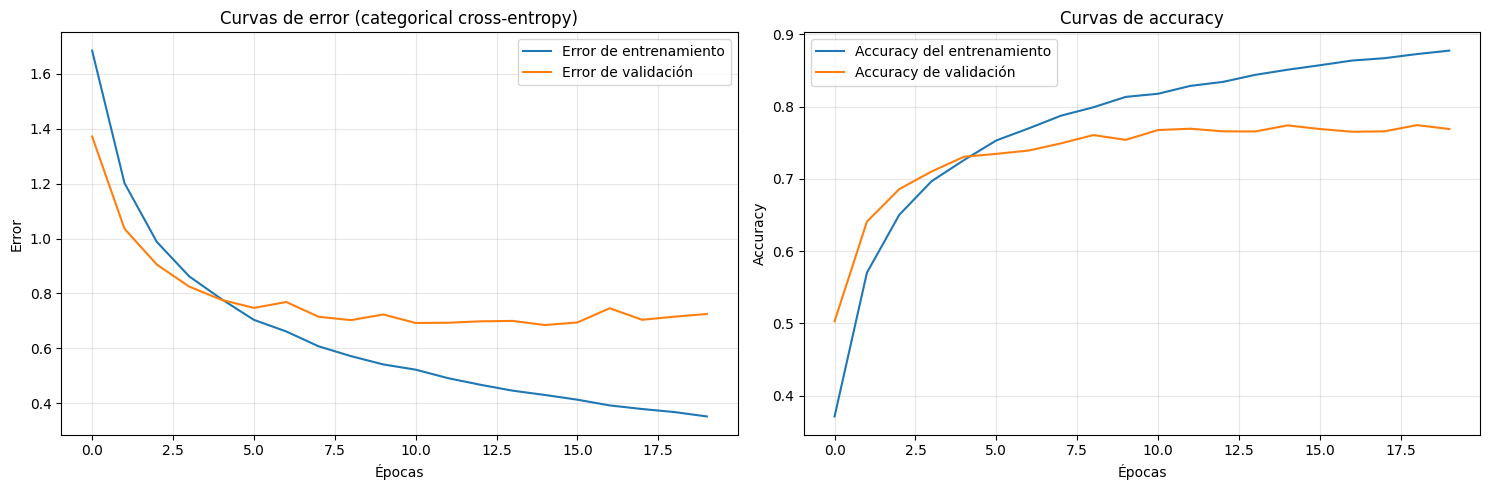

In [ ]:
plot_history_graphics(best_model_drop_12[2])

In [ ]:
print(f'Categorical cross-entropy: {best_model_drop_12[1]:.4f}')
print(f'Accuracy: {best_model_drop_12[0]:.4f} ({best_model_drop_12[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_drop_12[0]:.4f} ({(1-best_model_drop_12[0])*100:.2f}%)')

Categorical cross-entropy: 0.7040
Accuracy: 0.7778 (77.78%)
Error Rate: 0.2222 (22.22%)


In [ ]:
model_drop_21 = create_model_dropout(0.5, False)
model_drop_21.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_drop_21.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
best_model_drop_21 = train_model_rounds_ex1(model_drop_21, ROUNDS, EPOCHS, "ex2_drop_21")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3212 - loss: 1.8087
Epoch 1: val_accuracy improved from None to 0.56660, saving model to ./chk/ex2_drop_21/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex2_drop_21/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.4224 - loss: 1.5620 - val_accuracy: 0.5666 - val_loss: 1.2503
Epoch 2/20
1401/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5817 - loss: 1.1663
Epoch 2: val_accuracy improved from 0.56660 to 0.63240, saving model to ./chk/ex2_drop_21/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex2_drop_21/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5993 - loss: 1.1222 - val_accuracy: 0.6324 - val_loss: 1.1070
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6624 - loss: 0.9569
Epoch 3: val_accuracy improved from 0.63240 to 0.69140, saving model to ./chk/ex2_drop_21/round_4/3.keras

Epoch 3: finished saving model to ./chk/

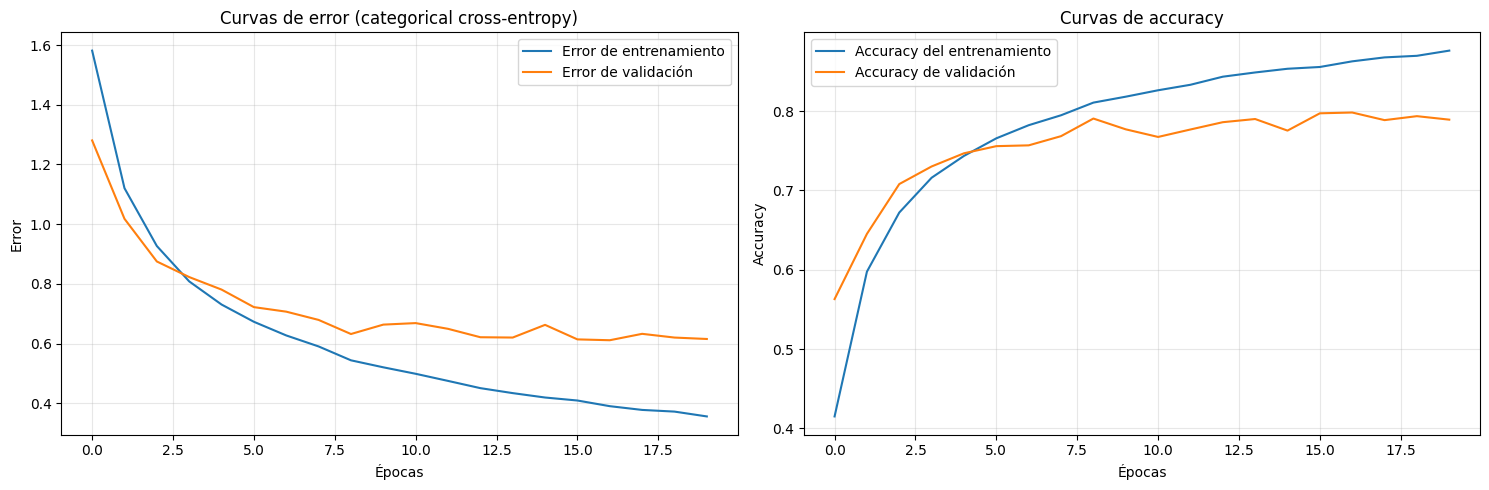

In [ ]:
plot_history_graphics(best_model_drop_21[2])

In [ ]:
print(f'Categorical cross-entropy: {best_model_drop_21[1]:.4f}')
print(f'Accuracy: {best_model_drop_21[0]:.4f} ({best_model_drop_21[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_drop_21[0]:.4f} ({(1-best_model_drop_21[0])*100:.2f}%)')

Categorical cross-entropy: 0.6434
Accuracy: 0.7860 (78.60%)
Error Rate: 0.2140 (21.40%)


In [ ]:
model_drop_22 = create_model_dropout(0.5, True)
model_drop_22.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_drop_22.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
best_model_drop_22 = train_model_rounds_ex1(model_drop_22, ROUNDS, EPOCHS, "ex2_drop_22")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2502 - loss: 1.9789
Epoch 1: val_accuracy improved from None to 0.49280, saving model to ./chk/ex2_drop_22/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex2_drop_22/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.3335 - loss: 1.7674 - val_accuracy: 0.4928 - val_loss: 1.5052
Epoch 2/20
1405/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4693 - loss: 1.4283
Epoch 2: val_accuracy improved from 0.49280 to 0.53680, saving model to ./chk/ex2_drop_22/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex2_drop_22/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4918 - loss: 1.3794 - val_accuracy: 0.5368 - val_loss: 1.2966
Epoch 3/20
1404/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5542 - loss: 1.2361
Epoch 3: val_accuracy improved from 0.53680 to 0.62360, saving model to ./chk/ex2_drop_22/round_4/3.keras

Epoch 3: finished saving model to ./chk/

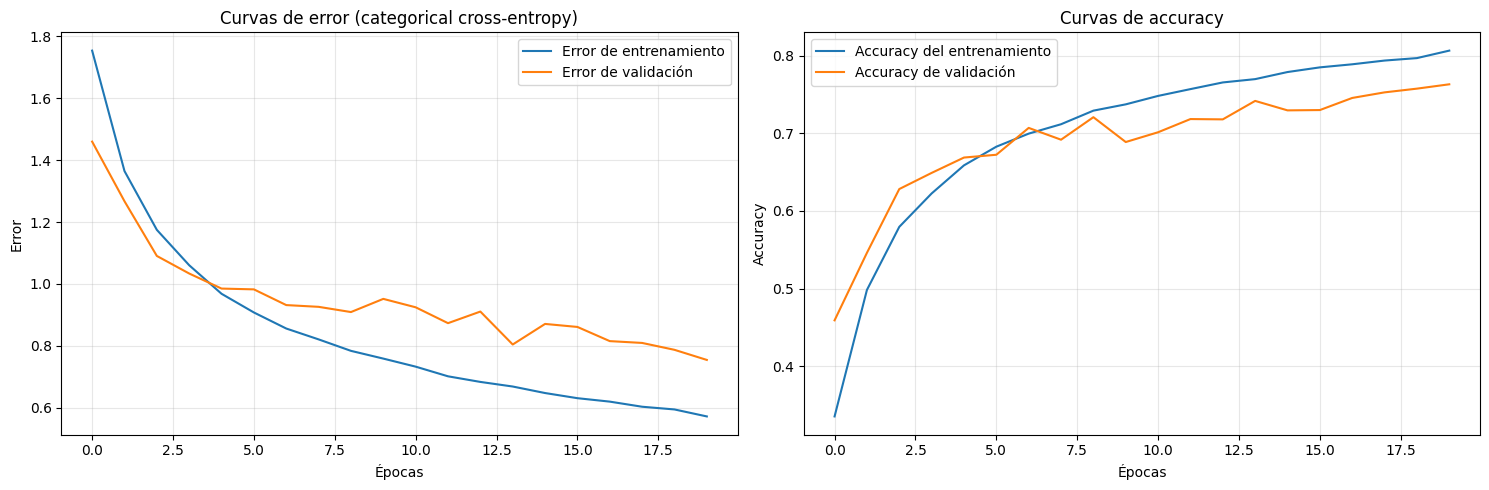

In [ ]:
plot_history_graphics(best_model_drop_22[2])

In [ ]:
print(f'Categorical cross-entropy: {best_model_drop_22[1]:.4f}')
print(f'Accuracy: {best_model_drop_22[0]:.4f} ({best_model_drop_22[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_drop_22[0]:.4f} ({(1-best_model_drop_22[0])*100:.2f}%)')

Categorical cross-entropy: 0.7680
Accuracy: 0.7557 (75.57%)
Error Rate: 0.2443 (24.43%)


In [17]:
model_drop_exp = create_model_dropout(0.5, True)
model_drop_exp.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 64)             │       252,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_drop_exp.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
best_model_drop_exp = train_model_rounds_ex1(model_drop_exp, ROUNDS, 40, "ex2_drop_22")

Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1267 - loss: 2.2383
Epoch 1: val_accuracy improved from None to 0.28960, saving model to ./chk/ex2_drop_22/round_4/1.keras

Epoch 1: finished saving model to ./chk/ex2_drop_22/round_4/1.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.1783 - loss: 2.1024 - val_accuracy: 0.2896 - val_loss: 1.8727
Epoch 2/40
1401/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3140 - loss: 1.7789
Epoch 2: val_accuracy improved from 0.28960 to 0.40880, saving model to ./chk/ex2_drop_22/round_4/2.keras

Epoch 2: finished saving model to ./chk/ex2_drop_22/round_4/2.keras
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3432 - loss: 1.7097 - val_accuracy: 0.4088 - val_loss: 1.6163
Epoch 3/40
1399/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4243 - loss: 1.5285
Epoch 3: val_accuracy improved from 0.40880 to 0.50780, saving model to ./chk/ex2_drop_22/round_4/3.keras

Epoch 3: finished saving model to ./chk/e

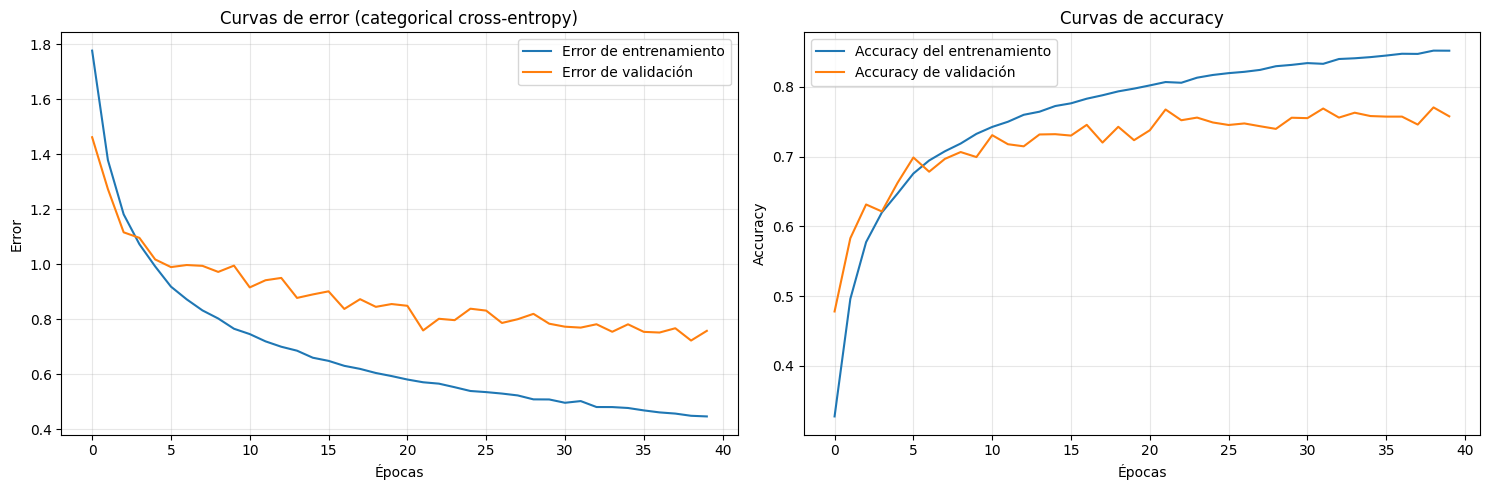

In [22]:
plot_history_graphics(best_model_drop_exp[2])

In [23]:
print(f'Categorical cross-entropy: {best_model_drop_exp[1]:.4f}')
print(f'Accuracy: {best_model_drop_exp[0]:.4f} ({best_model_drop_exp[0]*100:.2f}%)')
print(f'Error Rate: {1-best_model_drop_exp[0]:.4f} ({(1-best_model_drop_exp[0])*100:.2f}%)')

Categorical cross-entropy: 0.7217
Accuracy: 0.7672 (76.72%)
Error Rate: 0.2328 (23.28%)


##Conclusiones

### Uso de Dropout

La técnica Dropout utilizada en esta sección es una técnica de regularización que consiste en desactivar neuronas con una probabilidad $p \in [0,1]$. Para mantener consistente el resultado de la red, la salida de cada nodo es multiplicada por un factor $1/p$. Este proceso se puede interpretar como el de entrenar a un ensamble de redes diferentes para resolver un mismo problema. De esta manera, la red ve el conjunto de entrenamiento de diferentes formas permitiéndole así generalizar mejor. Sin embargo, es posible que todas aprendan algo erróneo. Afortunadamente, Dropout es capaz de cancelar estos errores, pues es muy poco probable que todas las redes cometan los mismos errores.

Otra forma de pensarlo es que la red puede estar sobreajustando por depender mucho de algunas neuronas especificas. Con Dropout eliminamos esas dependencias y obligamos a la totalidad de la red a que forme parte activa del proceso de aprendizaje. En otras palabras, se reduce la co-dependencia entre neuronas y se aumenta la capacidad de generalizar.

### Análisis de los gráficos

*   **$p = 0.2$ y una capa de Dropout:** Como se pudo observar en el Ejercicio 1, las modificaciones planteadas nos permitieron obtener un $\approx76.5\%$ de accuracy en test. Mientras, con esta configuración de Dropout, se obtiene un resultado no muy diferente del recién mencionado: $\approx77\%$ de accuracy de test.

    Además, se observa sobreajuste, similar al observado en el Ejercicio 1. Es decir, se observa que, tanto las curvas de error (categorical cross-entropy) como las de accuracy tienden a separarse según aumentan las epocas.

*   **$p = 0.2$ y dos capas de Dropout:** Con dos capas de Dropout, el accuracy de test es de $\approx77.7\%$, lo cual es $\approx1\%$ mejor que la red original.
El modelo sigue mostrando sobreajuste.

*   **$p = 0.5$ y una capa de Dropout:** El valor de $p$ elegido parece finalmente comenzar a reducir el sobreajuste aunque muy lentamente.
Se obtuvo un accuracy de test de $\approx78.6\%$ lo cual es una mejora de $\approx2\%$ respecto del modelo original.
Se puede apreciar que el sobreajuste disminuye respecto a los casos anteriores.

*   **$p = 0.5$ y dos capas de Dropout:** Finalmente, el accuracy de test que se obtiene es de $\approx75.5\%$, $\approx1\%$ peor que la red original. Esto significa que se agrega complejidad al modelo y sin ninguna mejoría en las predicciones, lo cual no es deseable. A pesar de esto, se ha logrado reducir el sobreajuste considerablemente respecto a las configuraciones anteriores.

Habiendo visto los 4 resultados podemos afirmar que, en este problema en particular, el valor $p = 0.2$ no es lo suficientemente agresivo como para reducir el sobreajuste. Por otro lado, $p = 0.5$, sí logra reducirlo. Aun asi, la diferencia yace en la cantidad de capas de Dropout, siendo el modelo con mejor performance el que tiene solo una capa por sobre el que tiene dos, aunque este ultimo esté mas ajustado.

¿Porque utilizando solo una capa de Dropout se obtiene mejor accuracy que con dos capas?

Una posibilidad puede ser que se está generando un cuello de botella, es decir, luego de desactivar aproximadamente la mitad de las neuronas en dos capas distintas (consecutivas en este caso, considerando que la capa de maxpooling no es 'entrenable') dificulta la capacidad de la red de propagar los errores en cada mini-batch.

En base a lo discutido, se elije como modelo optimo al que utiliza $p = 0.5$ y una capa de Dropout.

## Ejercicio 3. Data Augmentation

In [ ]:
img_height = 32
img_width = 32

data_augmentation = keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1)
])

model_aug = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            data_augmentation,
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
            layers.Dropout(0.5, name='dropout_1'),
            layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
            layers.Flatten(name='flatten'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(10, activation='softmax', name='output')
        ])

model_aug.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_aug.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_aug = model_aug.fit(
    x_train_split, y_train_split, epochs=40,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 443s 312ms/step - accuracy: 0.3336 - loss: 1.7943 - val_accuracy: 0.4424 - val_loss: 1.5568
Epoch 2/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 442s 313ms/step - accuracy: 0.4583 - loss: 1.4809 - val_accuracy: 0.5120 - val_loss: 1.3965
Epoch 3/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 452s 320ms/step - accuracy: 0.5106 - loss: 1.3466 - val_accuracy: 0.5690 - val_loss: 1.2328
Epoch 4/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 439s 312ms/step - accuracy: 0.5505 - loss: 1.2500 - val_accuracy: 0.5826 - val_loss: 1.2242
Epoch 5/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 444s 316ms/step - accuracy: 0.5802 - loss: 1.1823 - val_accuracy: 0.6172 - val_loss: 1.1239
Epoch 6/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 498s 313ms/step - accuracy: 0.5989 - loss: 1.1263 - val_accuracy: 0.6324 - val_loss: 1.0779
Epoch 7/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 447s 317ms/step - accuracy: 0.6127 - loss: 1.0918 - val_accuracy: 0.6372 - val_loss: 1.0654
Epoch 8/40
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accu

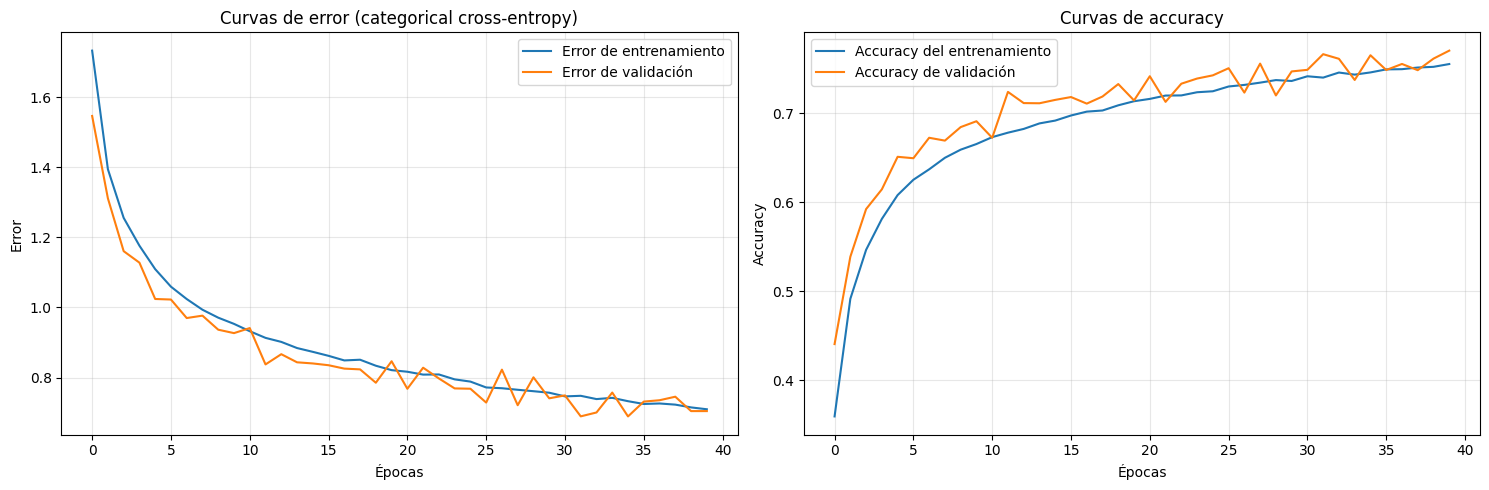

In [ ]:
plot_history_graphics(history_aug)

In [ ]:
model_aug.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7709 - loss: 0.6959


[0.6959003210067749, 0.7709000110626221]

In [ ]:
model_aug_80ep = keras.Sequential([
            keras.Input(shape=(32, 32, 3)),
            data_augmentation,
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_1'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'), # Añadido
            layers.MaxPooling2D(name='maxpool2d_1'), # Por defecto es 2x2
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
            layers.MaxPooling2D(name='maxpool2d_2'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_6'),
            layers.Dropout(0.5, name='dropout_1'),
            layers.MaxPooling2D(name='maxpool2d_3'), # Añadido
            layers.Flatten(name='flatten'),
            layers.Dense(64, activation='relu', name='dense_1'),
            layers.Dense(128, activation='relu', name='dense_2'),
            layers.Dense(10, activation='softmax', name='output')
        ])

model_aug_80ep.summary()

Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_33 (Sequential)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_3 (MaxPooling2D)      │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,642 (1022.04 KB)

 Trainable params: 261,642 (1022.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_aug_80ep.compile(
    optimizer='adam',
    # Al usar una capa con activación softmax no hay que poner "from_logits=True" en la función de loss,
    # porque la red ya devuelve una distribución normalizada y la función calcule el loss apropiadamente.
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    # jit_compile=False
)
history_aug_80ep = model_aug_80ep.fit(
    x_train_split, y_train_split, epochs=80,
    validation_data=(x_val_split, y_val_split)
    )

Epoch 1/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.3280 - loss: 1.8202 - val_accuracy: 0.4464 - val_loss: 1.5511
Epoch 2/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4704 - loss: 1.4481 - val_accuracy: 0.5014 - val_loss: 1.4130
Epoch 3/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5314 - loss: 1.3023 - val_accuracy: 0.5716 - val_loss: 1.2389
Epoch 4/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.5671 - loss: 1.2064 - val_accuracy: 0.5860 - val_loss: 1.1619
Epoch 5/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.5932 - loss: 1.1407 - val_accuracy: 0.6514 - val_loss: 1.0193
Epoch 6/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6121 - loss: 1.0904 - val_accuracy: 0.6532 - val_loss: 1.0489
Epoch 7/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.6247 - loss: 1.0564 - val_accuracy: 0.6426 - val_loss: 1.0372
Epoch 8/80
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.6370 -

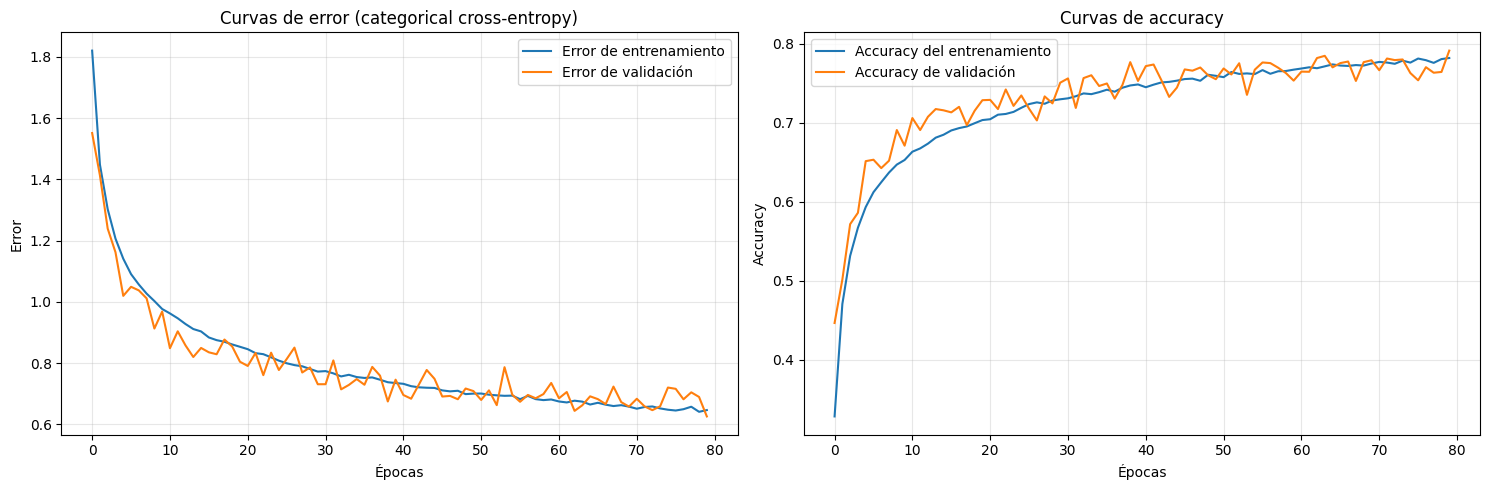

In [ ]:
plot_history_graphics(history_aug_80ep)

In [ ]:
model_aug_80ep.evaluate(x_test, y_test, verbose=2)

313/313 - 1s - 4ms/step - accuracy: 0.7887 - loss: 0.6293


[0.6293155550956726, 0.7886999845504761]

## Conclusiones

### Uso de data augmentation

La técnica data augmentation, al igual que dropout, es una técnica de regularización, esto mediante modificaciones a las imagenes como pueden ser: rotaciones, zoom, volteos (flip), etc. Estas modificaciones se realizan aleatoriamente sobre las imagenes del conjunto de entrenamiento al comienzo de cada epoca. El proposito de esto es que la red aprenda las mismas imagenes pero con cambios que no alteren lo que se quiere aprender, de este modo obligando a la red a ignorar detalles de las imagenes que pueden ser irrelevantes e incluso evitar que algun detalle repetitivo en las imagenes como puede ser un color, cierto nivel de iluminación o algun elemento del entorno que se repita, desvie el aprendizaje.

### Análisis de los gráficos

*   **$40$ epocas:** Se ve que, gracias a que se agregó data augmentation al conjunto de entrenamiento, la red logra elimiar por completo el sobreajuste y con un accuracy de validación, $\approx77\%$ similar al mejor observado por dropout. Es decir que se está manteniendo una buena performance y eliminando el sobreajuste a la vez.
*   **$80$ epocas:** El proposito de la realización de un entrenamiento de $80$ epocas es poder observar que al aumentar la cantidad de epocas durante las cuales la red entrena, logra que su performance aumente tambien. Como se puede ver, efectivamente, aumenta la performance aunque de una manera demasiado lenta como para que sea util agregar mas epocas, por lo que, concluimos con un $\approx79\%$ de accuracy de validación, lo cual, es una mejora de $\approx5\%$ respecto al modelo original.

En el caso presentado en esta sección se realizan:

*   Volteo horizontal aleatorio.
*   Rotación aleatoria en el intervalo $[-36°, 36°]$
*   Zoom aleatorio por un factor en el intervalo $[0.9, 1.1]$

Los intervalos se obtuvieron analizando como funcionan RandomRotation y RandomZoom de keras.

## Ejercicio 4. Transfer Learning

TODO: Hay que hacer con dropout? Probablemente hay que agregar las optimizaciones del 1)!

In [ ]:
x_train = np.array([np.array(element) for element in ds_train['img']])
y_train = np.array(ds_train['label'])

x_train = x_train.astype('float32') / 255.0

In [ ]:
x_test = np.array(ds_test['img'])
y_test = np.array(ds_test['label'])

x_test = x_test.astype('float32') / 255.0

In [ ]:
# Elegimos arbitrariamente las últimas dos clases para simplificar su eliminación
cond = y_train < 8
x_train8 = x_train[cond]
y_train8 = y_train[cond]

In [ ]:
y_train8

array([0, 6, 0, ..., 1, 1, 5], shape=(40000,))

In [ ]:
cond = y_test < 8
x_test8 = x_test[cond]
y_test8 = y_test[cond]

In [ ]:
y_test8

array([3, 0, 6, ..., 5, 1, 7], shape=(8000,))

In [ ]:
model_cifar8 = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv2d_1'),
    layers.MaxPooling2D(name='maxpool2d_1'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_3'),
    layers.MaxPooling2D(name='maxpool2d_2'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_4'),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2d_5'),
    layers.Flatten(name='flatten'),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(128, activation='relu', name='dense_2'),
    layers.Dense(128, activation='relu', name='dense_3'),
    layers.Dense(8, activation='softmax', name='output') # 8 capas de salida
])

In [ ]:
model_cifar8.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_1 (MaxPooling2D)      │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool2d_2 (MaxPooling2D)      │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 418,248 (1.60 MB)

 Trainable params: 418,248 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

TODO: Loss elegido ok? Métricas?

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train8_split, x_val8_split, y_train8_split, y_val8_split = \
    train_test_split(x_train8, y_train8, test_size=0.1, stratify=y_train8)

TODO: Cantidad épocas? Usar Model Checkpoint para agarrar con la mejor validación?

In [ ]:
history_cifar8 = model_cifar8.fit(
    x_train8_split, y_train8_split, epochs=10,
    validation_data=(x_val8_split, y_val8_split)
)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4166 - loss: 1.5287 - val_accuracy: 0.5393 - val_loss: 1.2303
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5798 - loss: 1.1395 - val_accuracy: 0.6133 - val_loss: 1.0741
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6432 - loss: 0.9814 - val_accuracy: 0.6560 - val_loss: 0.9502
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6928 - loss: 0.8581 - val_accuracy: 0.6720 - val_loss: 0.9124
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.7276 - loss: 0.7627 - val_accuracy: 0.6917 - val_loss: 0.8651
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.7566 - loss: 0.6846 - val_accuracy: 0.7005 - val_loss: 0.8690
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7852 - loss: 0.6083 - val_accuracy: 0.7153 - val_loss: 0.8567
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8075 - loss: 0.5443 - 

In [ ]:
cond = y_train >= 8
x_train2 = x_train[cond] - 8   # Restamos para tener clases 0,1
y_train2 = y_train[cond] - 8

In [ ]:
y_train2

array([0, 0, 1, ..., 0, 1, 1], shape=(10000,))

In [ ]:
cond = y_test >= 8
x_test2 = x_test[cond] - 8
y_test2 = y_test[cond] - 8

In [ ]:
y_test2

array([0, 0, 1, ..., 0, 0, 0], shape=(2000,))

In [ ]:
model_cifar8.pop()
for layer in model_cifar8.layers:
    layer.trainable = False

In [ ]:
model_cifar8.summary(show_trainable = True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   N   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 417,216 (1.59 MB)

 Optimizer params: 836,498 (3.19 MB)

In [ ]:
model_cifar2 = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2.summary()

Model: "sequential_82"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 258 (1.01 KB)

 Non-trainable params: 417,216 (1.59 MB)

In [ ]:
model_cifar2.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2 = model_cifar2.fit(
    x_train2_split, y_train2_split, epochs=20,
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5082 - loss: 1.6986 - val_accuracy: 0.5690 - val_loss: 0.6861
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6096 - loss: 0.6635 - val_accuracy: 0.6540 - val_loss: 0.6247
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6508 - loss: 0.6318 - val_accuracy: 0.7050 - val_loss: 0.5935
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6659 - loss: 0.6137 - val_accuracy: 0.6580 - val_loss: 0.5999
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6660 - loss: 0.6142 - val_accuracy: 0.6990 - val_loss: 0.5845
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6727 - loss: 0.6117 - val_accuracy: 0.6440 - val_loss: 0.6325
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6746 - loss: 0.6048 - val_accuracy: 0.6630 - val_loss: 0.5950
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6681 - loss: 0.6095 - val_accuracy: 0

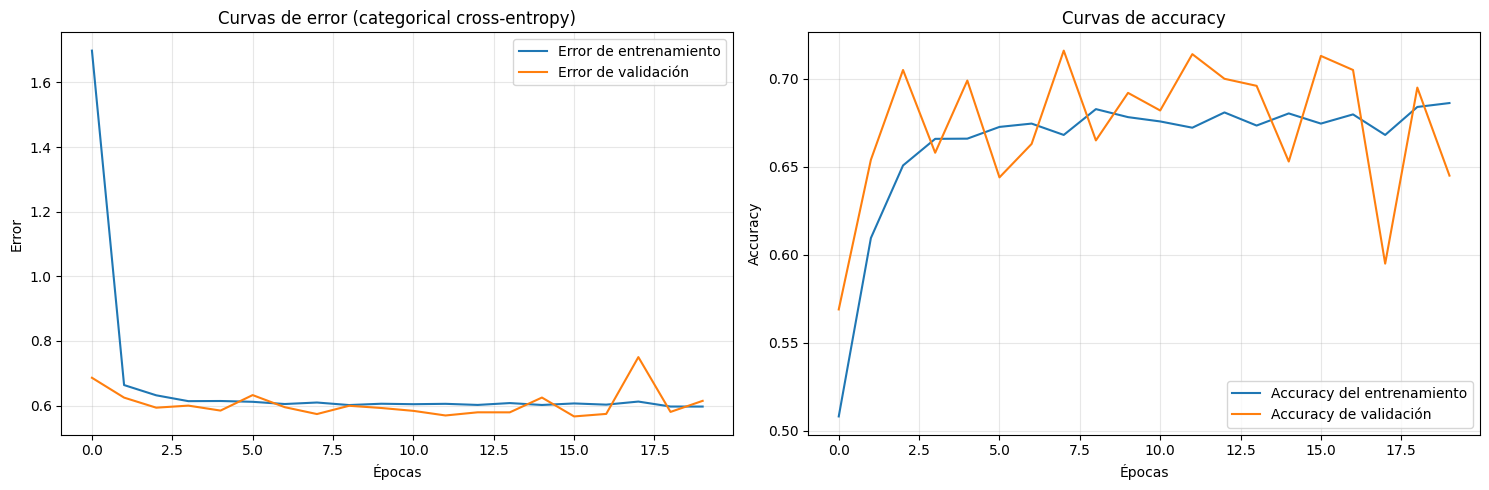

In [ ]:
plot_history_graphics(history_cifar2)

In [ ]:
model_cifar2.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 4ms/step - accuracy: 0.2290 - loss: 1.8824


[1.882355809211731, 0.2290000021457672]

#### Descongelando la última capa

In [ ]:
model_cifar8.layers[-1].trainable = True

In [ ]:
model_cifar8.summary(show_trainable = True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 1,253,714 (4.78 MB)

 Trainable params: 16,512 (64.50 KB)

 Non-trainable params: 400,704 (1.53 MB)

 Optimizer params: 836,498 (3.19 MB)

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
model_cifar2_unfreeze1 = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2_unfreeze1.summary()

Model: "sequential_83"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 16,770 (65.51 KB)

 Non-trainable params: 400,704 (1.53 MB)

In [ ]:
model_cifar2_unfreeze1.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2_unfreeze1 = model_cifar2_unfreeze1.fit(
    x_train2_split, y_train2_split, epochs=20,
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5548 - loss: 0.9993 - val_accuracy: 0.6020 - val_loss: 0.6641
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6611 - loss: 0.6272 - val_accuracy: 0.7040 - val_loss: 0.5884
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6797 - loss: 0.6072 - val_accuracy: 0.7180 - val_loss: 0.5669
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6821 - loss: 0.6050 - val_accuracy: 0.7150 - val_loss: 0.5671
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6844 - loss: 0.6016 - val_accuracy: 0.7260 - val_loss: 0.5637
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6879 - loss: 0.5971 - val_accuracy: 0.7250 - val_loss: 0.5636
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6842 - loss: 0.6035 - val_accuracy: 0.7200 - val_loss: 0.5678
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6978 - loss: 0.5866 - val_accuracy: 0.

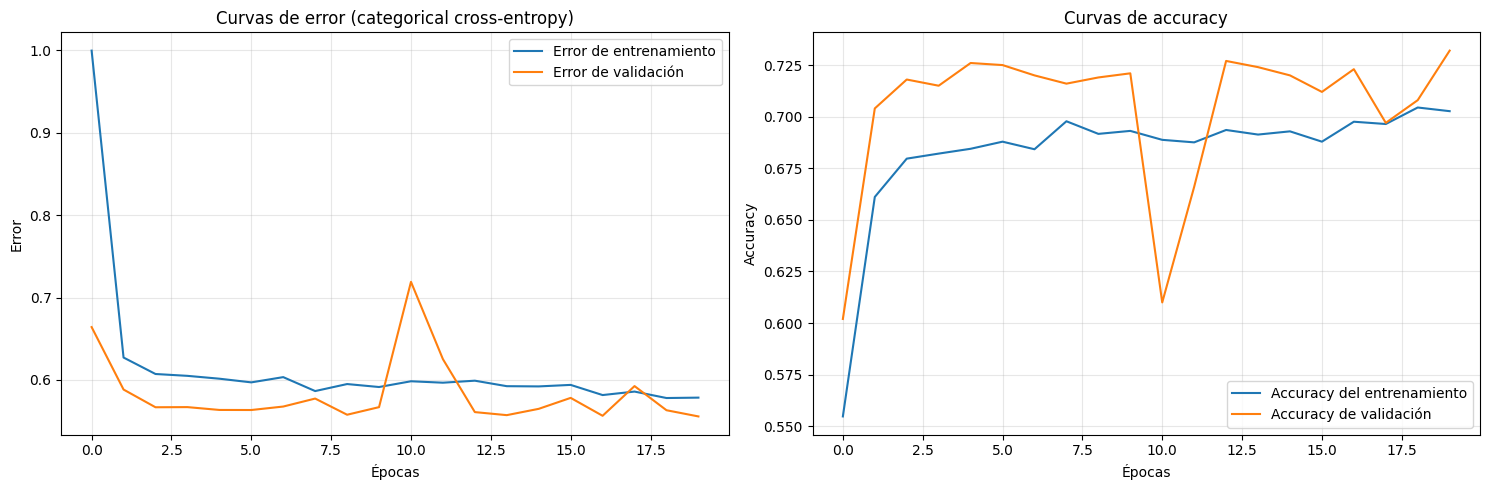

In [ ]:
plot_history_graphics(history_cifar2_unfreeze1)

In [ ]:
model_cifar2_unfreeze1.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 4ms/step - accuracy: 0.7045 - loss: 0.5717


[0.5717491507530212, 0.7045000195503235]

#### Descongelando las capas densas

(TODO) Al ver que no se obtuvieron mejores resultados, elegimos descongelar todas las capas densas:

In [ ]:
for i in [-1,-2,-3]:
    model_cifar8.layers[i].trainable = True

In [ ]:
model_cifar8.summary(show_trainable=True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 417,216 (1.59 MB)

 Trainable params: 287,040 (1.09 MB)

 Non-trainable params: 130,176 (508.50 KB)

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
model_cifar2_unfreeze_dense = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2_unfreeze_dense.summary()

Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 287,298 (1.10 MB)

 Non-trainable params: 130,176 (508.50 KB)

In [ ]:
model_cifar2_unfreeze_dense.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2_unfreeze_dense = model_cifar2_unfreeze_dense.fit(
    x_train2_split, y_train2_split, epochs=10, # TODO: Tiene buenos resultados con 10 (e incluso menos épocas? checkpoints?)
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6964 - loss: 0.5818 - val_accuracy: 0.7260 - val_loss: 0.5447
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7700 - loss: 0.4894 - val_accuracy: 0.7300 - val_loss: 0.5444
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7953 - loss: 0.4498 - val_accuracy: 0.7190 - val_loss: 0.5474
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7932 - loss: 0.4436 - val_accuracy: 0.8110 - val_loss: 0.3924
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8056 - loss: 0.4275 - val_accuracy: 0.8310 - val_loss: 0.3683
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8170 - loss: 0.3994 - val_accuracy: 0.8310 - val_loss: 0.3657
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8200 - loss: 0.3939 - val_accuracy: 0.8390 - val_loss: 0.3526
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8281 - loss: 0.3830 - val_accuracy: 0.

TODO: Model checkpoint?

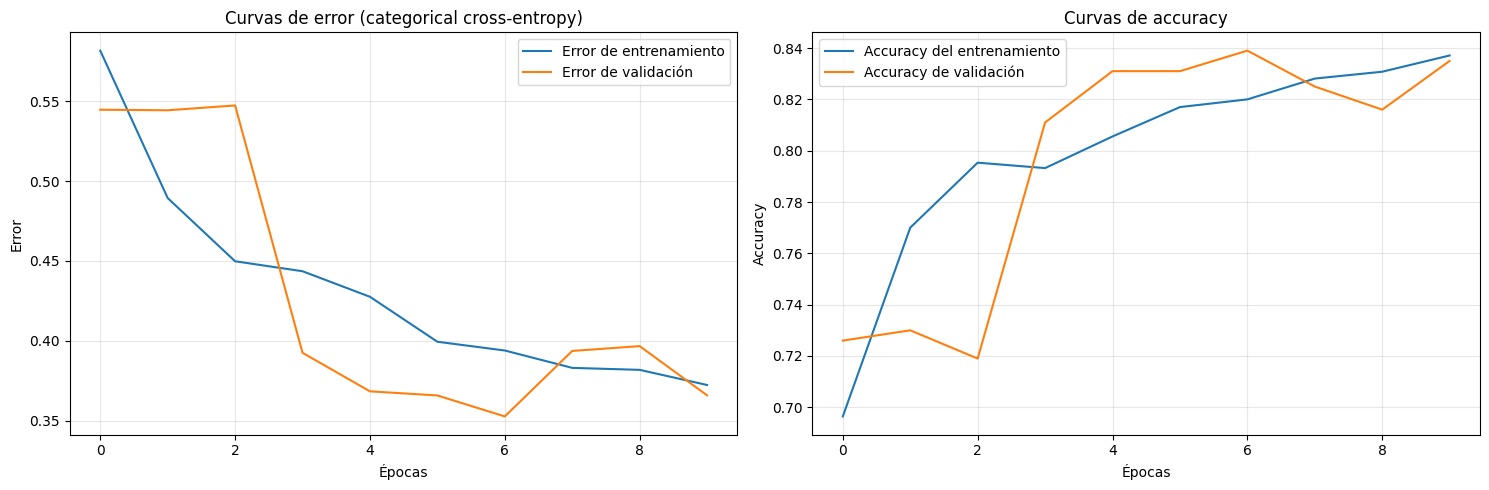

In [ ]:
plot_history_graphics(history_cifar2_unfreeze_dense)

In [ ]:
model_cifar2_unfreeze_dense.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 5ms/step - accuracy: 0.8170 - loss: 0.4165


[0.41654080152511597, 0.8169999718666077]

#### Descongelando las últimas capas convolucionales

In [ ]:
for i in range(-6,0):
    model_cifar8.layers[i].trainable = True

In [ ]:
model_cifar8.summary(show_trainable=True)

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ conv2d_1 (Conv2D)           │ (None, 32, 32, 32)    │        896 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)    │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_2 (Conv2D)           │ (None, 16, 16, 64)    │     18,496 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_3 (Conv2D)           │ (None, 16, 16, 64)    │     36,928 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ maxpool2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)      │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_4 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ conv2d_5 (Conv2D)           │ (None, 8, 8, 64)      │     36,928 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 4096)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 64)            │    262,208 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 128)           │      8,320 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_3 (Dense)             │ (None, 128)           │     16,512 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 417,216 (1.59 MB)

 Trainable params: 360,896 (1.38 MB)

 Non-trainable params: 56,320 (220.00 KB)

In [ ]:
model_cifar8.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
model_cifar2_unfreeze_lastconv = keras.Sequential([
    model_cifar8,
    layers.Dense(2, activation='softmax')
])

In [ ]:
model_cifar2_unfreeze_lastconv.summary()

Model: "sequential_99"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_81 (Sequential)      │ (None, 128)            │       417,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417,474 (1.59 MB)

 Trainable params: 361,154 (1.38 MB)

 Non-trainable params: 56,320 (220.00 KB)

In [ ]:
model_cifar2_unfreeze_lastconv.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy'],
    # Fix para la GPU de Ariel (si se soporta oficialmente la GPU, se puede quitar)
    jit_compile=False
)

In [ ]:
x_train2_split, x_val2_split, y_train2_split, y_val2_split = \
    train_test_split(x_train2, y_train2, test_size=0.1, stratify=y_train2)

In [ ]:
history_cifar2_unfreeze_lastconv = model_cifar2_unfreeze_lastconv.fit(
    x_train2_split, y_train2_split, epochs=10, # TODO: Tiene buenos resultados con 10 (e incluso menos épocas? checkpoints?)
    validation_data=(x_val2_split, y_val2_split)
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7614 - loss: 0.5180 - val_accuracy: 0.8280 - val_loss: 0.4069
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8030 - loss: 0.4337 - val_accuracy: 0.7060 - val_loss: 0.6810
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8077 - loss: 0.4172 - val_accuracy: 0.8430 - val_loss: 0.3706
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8368 - loss: 0.3685 - val_accuracy: 0.8250 - val_loss: 0.4020
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8331 - loss: 0.3679 - val_accuracy: 0.8530 - val_loss: 0.3542
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8518 - loss: 0.3461 - val_accuracy: 0.7440 - val_loss: 0.6184
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8469 - loss: 0.3443 - val_accuracy: 0.8390 - val_loss: 0.4022
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8597 - loss: 0.3288 - val_accuracy: 0.

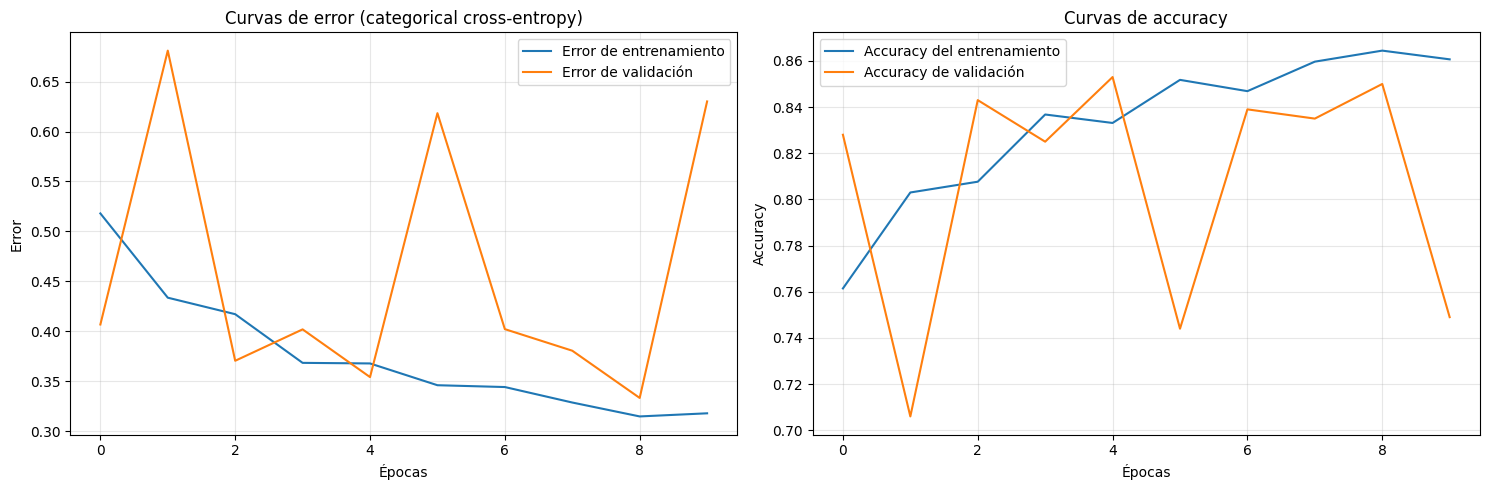

In [ ]:
plot_history_graphics(history_cifar2_unfreeze_lastconv)

In [ ]:
model_cifar2_unfreeze_lastconv.evaluate(x_test2, y_test2, verbose=2)

63/63 - 0s - 5ms/step - accuracy: 0.7440 - loss: 0.6127


[0.6126516461372375, 0.7440000176429749]

TODO: Model checkpoint? Probar con cantidades de capas intermedias? Probar con más? Notar que el óptimo acá fue aún mejor respecto al anterior, entonces capaz usando checkpoint va mejor el accuracy respecto a test.
    Métricas?